#### imports

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils

In [21]:
DATASET_PATH = Path("../datasets/disasters_merged_all_feats.csv")
EVENT_GROUP = 'Wildfire'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data Preparation

In [22]:
df = pd.read_csv(DATASET_PATH)

### Group by event type

In [23]:
event_group_dfs = {
    'Hail': df[df['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df[df['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [24]:
df = event_group_dfs[EVENT_GROUP]

### Data normalization

In [25]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

In [26]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [27]:
# targets log transformation
Y = np.log1p(Y)

In [28]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [29]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


### Dataset split

In [30]:
# # conversion to tensors and move to device
# X_train = torch.tensor(np.ascontiguousarray(X_train), dtype=torch.float32).to(device)
# Y_train = torch.tensor(np.ascontiguousarray(Y_train), dtype=torch.float32).to(device)

# X_val = torch.tensor(np.ascontiguousarray(X_val), dtype=torch.float32).to(device)
# Y_val = torch.tensor(np.ascontiguousarray(Y_val), dtype=torch.float32).to(device)

# X_test = torch.tensor(np.ascontiguousarray(X_test), dtype=torch.float32).to(device)
# Y_test = torch.tensor(np.ascontiguousarray(Y_test), dtype=torch.float32).to(device)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

In [31]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

## Model

### Model definition

In [32]:
BATCH_SIZE = 512

In [33]:
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=12,
    hidden_features=[128, 128],
    bins=8
)

In [34]:
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

### Model Evaluation

In [35]:
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

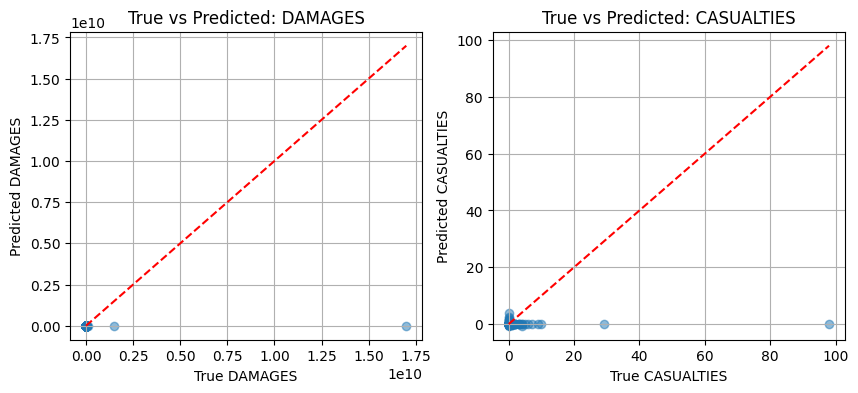

In [67]:
# Run inference for the test set and plot results for damages and casualties
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))

    # Plot for each target
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.subplot(1,2,2)
    plt.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Predicted {target_cols[1]}")
    plt.title(f"True vs Predicted: {target_cols[1]}")
    plt.plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    plt.grid()
    plt.show()

run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS)

## Result Analysis

In [37]:
X_test = X_test.to(device)
Y_test = Y_test.to(device)
pass

### Metrics & statistics #1

Negative Log-Likelihood

In [38]:
with torch.no_grad():
    X = X_test.to(device)
    Y = Y_test.to(device)
    test_nll = -flow(X).log_prob(Y).mean().item()

print(f"Test NLL: {test_nll:.3f}")

Test NLL: -0.261


In [39]:
def sample_predictions(flow, X, n_samples=1000):
    samples = []
    with torch.no_grad():
        for x in X:
            dist = flow(x.unsqueeze(0))
            s = dist.sample((n_samples,))  # [S,1,2]
            samples.append(s.squeeze(1))
    return torch.stack(samples)  # [N,S,2]

In [40]:
# Draw Posterior Predictive Samples
pred_samples = sample_predictions(flow, X_test[:200], n_samples=1000)

In [41]:
def invert_transform(samples):
    s = samples.reshape(-1,2).cpu().numpy()
    s = y_scaler.inverse_transform(s)
    s = np.expm1(s)
    return s.reshape(samples.shape)


In [42]:
# Undo Scaling and Log
pred_samples = invert_transform(pred_samples)
Y_true = invert_transform(Y_test[:200].unsqueeze(1)).squeeze(1)

#### Marginal Distribution Plots

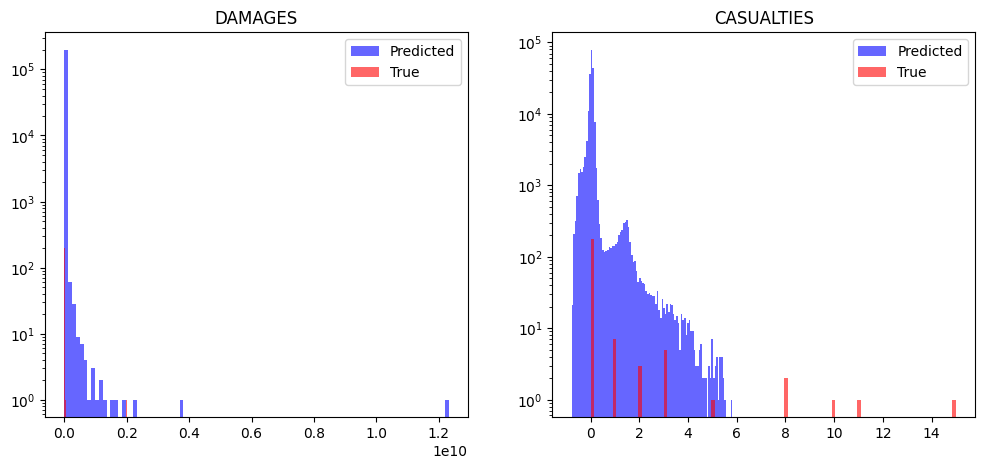

In [43]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(pred_samples[:,:,0].flatten(), bins=100, alpha=0.6, color='blue', label='Predicted')
plt.hist(Y_true[:,0], bins=100, alpha=0.6, color='red', label='True')
plt.yscale("log")
plt.title("DAMAGES")
plt.legend()

plt.subplot(1,2,2)
plt.hist(pred_samples[:,:,1].flatten(), bins=100, alpha=0.6, color='blue', label='Predicted')
plt.hist(Y_true[:,1], bins=100, alpha=0.6, color='red', label='True')
plt.yscale("log")
plt.title("CASUALTIES")
plt.legend()

plt.show()


#### Joint Distribution (Correlation)

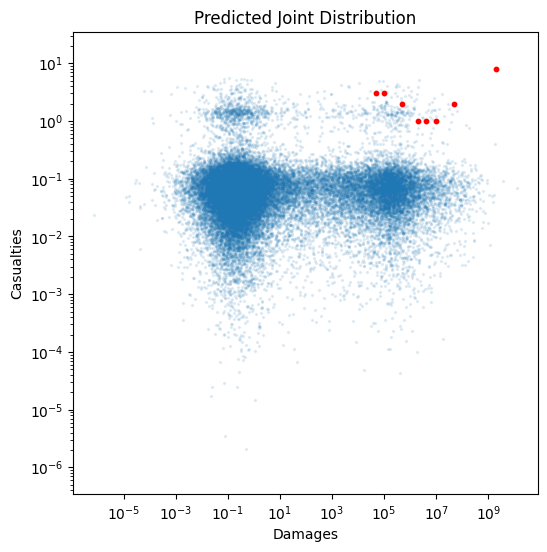

In [44]:
plt.figure(figsize=(6,6))
plt.scatter(
    pred_samples[:,:,0].flatten(),
    pred_samples[:,:,1].flatten(),
    s=2, alpha=0.1
)
plt.scatter(Y_true[:,0], Y_true[:,1], color="red", s=10)
plt.xlabel("Damages")
plt.ylabel("Casualties")
plt.xscale("log")
plt.yscale("log")
plt.title("Predicted Joint Distribution")
plt.show()


#### Coverage

In [45]:
lower = np.percentile(pred_samples, 5, axis=1)
upper = np.percentile(pred_samples, 95, axis=1)

inside = ((Y_true >= lower) & (Y_true <= upper))
coverage = inside.mean(axis=0)

print("90% coverage DAMAGES:", coverage[0])
print("90% coverage CASUALTIES:", coverage[1])


90% coverage DAMAGES: 0.875
90% coverage CASUALTIES: 0.9


#### Single-Event Posterior Plot

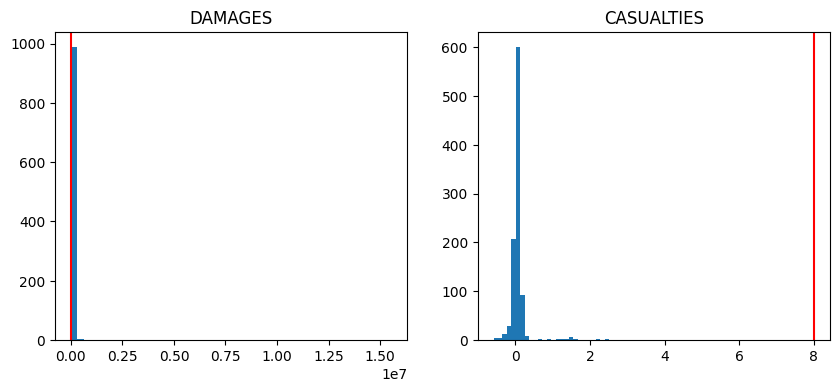

In [46]:
i = 5
s = pred_samples[i]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(s[:,0], bins=50)
plt.axvline(Y_true[i,0], color="red")
plt.title("DAMAGES")
plt.subplot(1,2,2)
plt.hist(s[:,1], bins=50)
plt.axvline(Y_true[i,1], color="red")
plt.title("CASUALTIES")
plt.show()


### Metrics & statistics #2

In [47]:
def sample_predictive(flow, x, n=10000):
    """
    x: torch tensor shape (1, X_DIM)
    returns samples in original scale: (n,2)
    """
    with torch.no_grad():
        dist = flow(x)
        samples = dist.sample((n,)).squeeze(1).cpu().numpy()

    samples = y_scaler.inverse_transform(samples)
    samples = np.expm1(samples)
    return samples


In [48]:
# random test sample
idx = np.random.randint(len(X_test))
x0 = X_test[idx:idx+1].to(next(flow.parameters()).device)
y_true = Y_test[idx].cpu().numpy()
y_true = np.expm1(y_scaler.inverse_transform(y_true.reshape(1,-1)))[0]

samples = sample_predictive(flow, x0)


#### 1. Joint Distribution Visualization

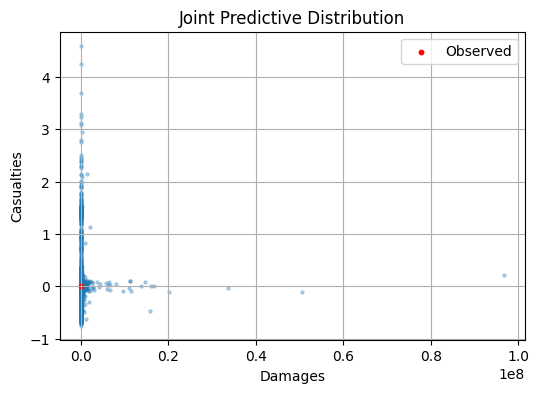

In [49]:
plt.figure(figsize=(6,4))
plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.3)
plt.scatter(y_true[0], y_true[1], color="red", s=10, label="Observed")
plt.xlabel("Damages")
plt.ylabel("Casualties")
plt.title("Joint Predictive Distribution")
plt.legend()
plt.grid()
plt.show()


#### 2. Marginal Distributions

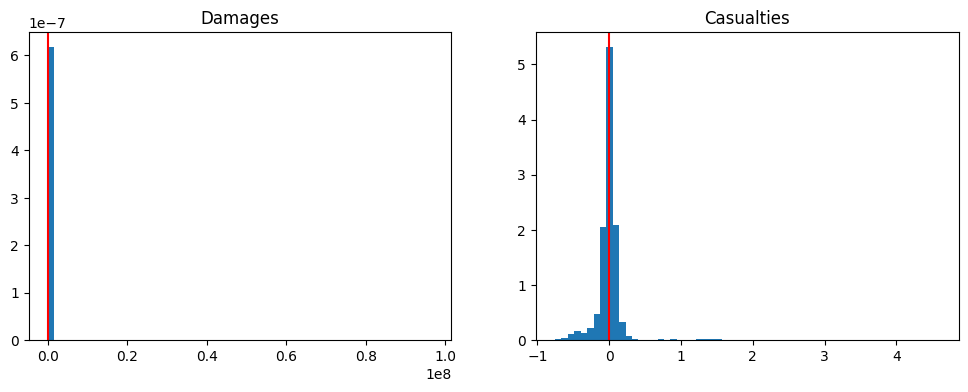

In [50]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(samples[:,0], bins=60, density=True)
axes[0].axvline(y_true[0], color="red")
axes[0].set_title("Damages")

axes[1].hist(samples[:,1], bins=60, density=True)
axes[1].axvline(y_true[1], color="red")
axes[1].set_title("Casualties")

plt.show()


#### 3. Output Correlation

In [51]:
corr = np.corrcoef(samples.T)[0,1]
print("Predicted correlation:", corr)


Predicted correlation: 0.0021412721574907527


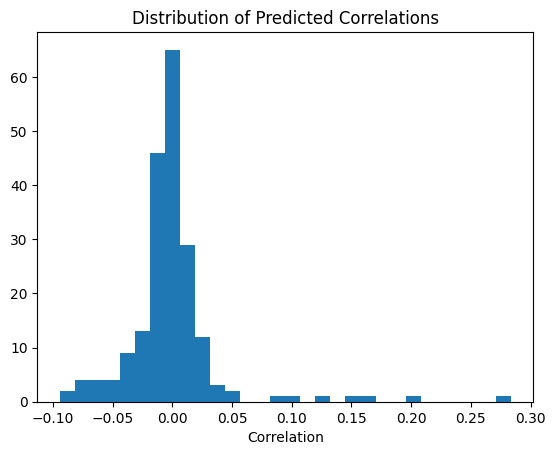

In [52]:
cors = []

for i in range(200):
    x = X_test[i:i+1].to(next(flow.parameters()).device)
    s = sample_predictive(flow, x, 1000)
    cors.append(np.corrcoef(s.T)[0,1])

plt.hist(cors, bins=30)
plt.xlabel("Correlation")
plt.title("Distribution of Predicted Correlations")
plt.show()


#### 4. Partial Dependence Plot (Single Feature)

In [53]:
feats = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED',
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

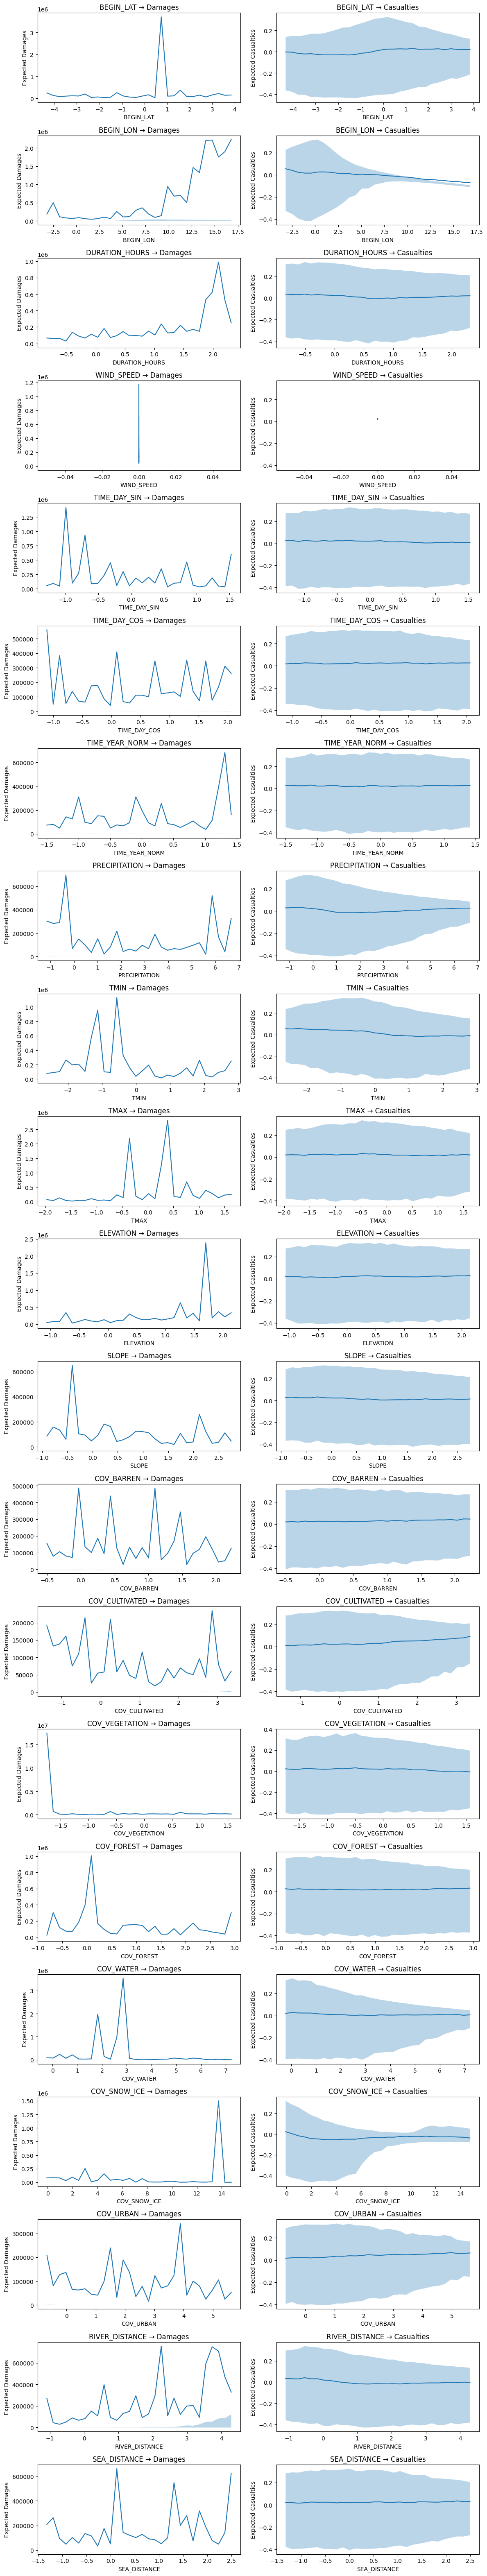

In [54]:
# Partial dependence for all features: damages and casualties, with uncertainty
n_feats = len(feats)
fig, axes = plt.subplots(n_feats, 2, figsize=(12, 3*n_feats), sharex=False)

for i, feature in enumerate(feats):
    k = X_COLS.index(feature)
    grid = np.linspace(X_train[:,k].min(), X_train[:,k].max(), 30)
    base = X_test.mean(0, keepdim=True)
    means_damages, q05_damages, q95_damages = [], [], []
    means_cas, q05_cas, q95_cas = [], [], []
    for g in grid:
        x = base.clone()
        x[0, k] = g
        s = sample_predictive(flow, x.to(next(flow.parameters()).device))
        means_damages.append(s[:,0].mean())
        q05_damages.append(np.percentile(s[:,0], 5))
        q95_damages.append(np.percentile(s[:,0], 95))
        means_cas.append(s[:,1].mean())
        q05_cas.append(np.percentile(s[:,1], 5))
        q95_cas.append(np.percentile(s[:,1], 95))
    # Damages
    ax = axes[i,0]
    ax.plot(grid, means_damages)
    ax.fill_between(grid, q05_damages, q95_damages, alpha=0.3)
    ax.set_ylabel("Expected Damages")
    ax.set_title(f"{feature} → Damages")
    # Casualties
    ax = axes[i,1]
    ax.plot(grid, means_cas)
    ax.fill_between(grid, q05_cas, q95_cas, alpha=0.3)
    ax.set_ylabel("Expected Casualties")
    ax.set_title(f"{feature} → Casualties")
    for a in axes[i]:
        a.set_xlabel(feature)
plt.tight_layout()
plt.show()


#### 5. ICE Curves (Heterogeneous Effects)

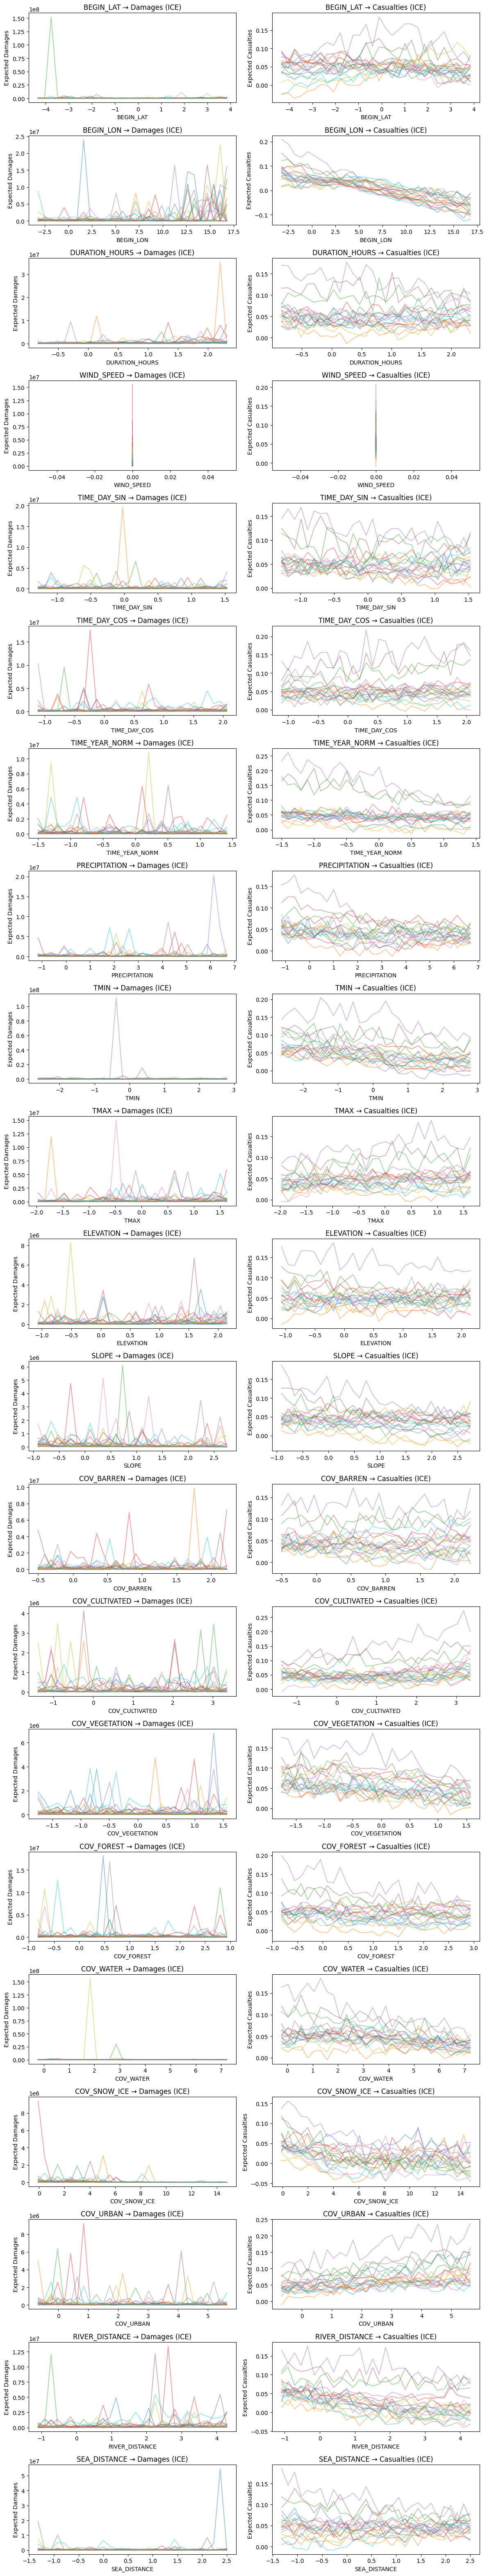

In [55]:
# ICE curves for all features: damages and casualties
n_feats = len(feats)
fig, axes = plt.subplots(n_feats, 2, figsize=(12, 3*n_feats), sharex=False)

n_ice = 20  # number of ICE curves per feature
for i, feature in enumerate(feats):
    k = X_COLS.index(feature)
    grid = np.linspace(X_train[:,k].min(), X_train[:,k].max(), 30)
    # Damages
    for j in range(n_ice):
        base = X_test[j:j+1].clone()
        curve_damages = []
        curve_cas = []
        for g in grid:
            x = base.clone()
            x[0, k] = g
            s = sample_predictive(flow, x.to(next(flow.parameters()).device), 500)
            curve_damages.append(s[:,0].mean())
            curve_cas.append(s[:,1].mean())
        axes[i,0].plot(grid, curve_damages, alpha=0.4)
        axes[i,1].plot(grid, curve_cas, alpha=0.4)
    axes[i,0].set_ylabel("Expected Damages")
    axes[i,0].set_title(f"{feature} → Damages (ICE)")
    axes[i,1].set_ylabel("Expected Casualties")
    axes[i,1].set_title(f"{feature} → Casualties (ICE)")
    for a in axes[i]:
        a.set_xlabel(feature)
plt.tight_layout()
plt.show()


#### 6. Counterfactual Location Comparison

In [56]:
x = X_test[10:11].clone()

urban_low = -2.0
urban_high = 2.0

x_low = x.clone()
x_high = x.clone()

x_low[0,k] = urban_low
x_high[0,k] = urban_high

s_low = sample_predictive(flow, x_low.to(next(flow.parameters()).device))
s_high = sample_predictive(flow, x_high.to(next(flow.parameters()).device))


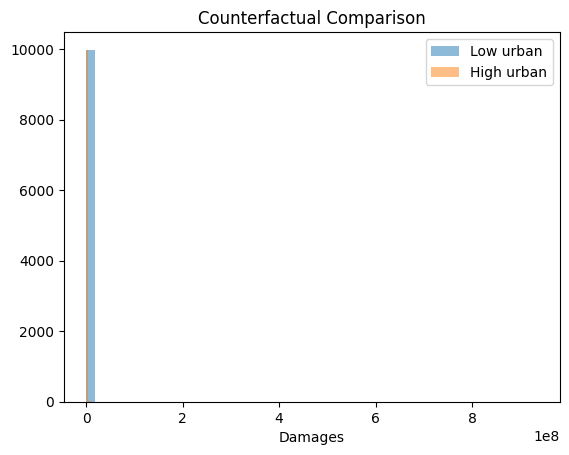

In [57]:
plt.hist(s_low[:,0], bins=50, alpha=0.5, label="Low urban")
plt.hist(s_high[:,0], bins=50, alpha=0.5, label="High urban")
plt.legend()
plt.xlabel("Damages")
plt.title("Counterfactual Comparison")
plt.show()


#### 7. Permutation Feature Importance

In [58]:
def permutation_importance(flow, X, Y, feature_index, n=500):
    idx = torch.randperm(len(X))[:n]
    Xp = X[idx].clone()
    Yp = Y[idx]

    with torch.no_grad():
        base = -flow(Xp).log_prob(Yp).mean().item()

    Xp[:,feature_index] = Xp[torch.randperm(len(Xp)),feature_index]

    with torch.no_grad():
        perm = -flow(Xp).log_prob(Yp).mean().item()

    return perm - base


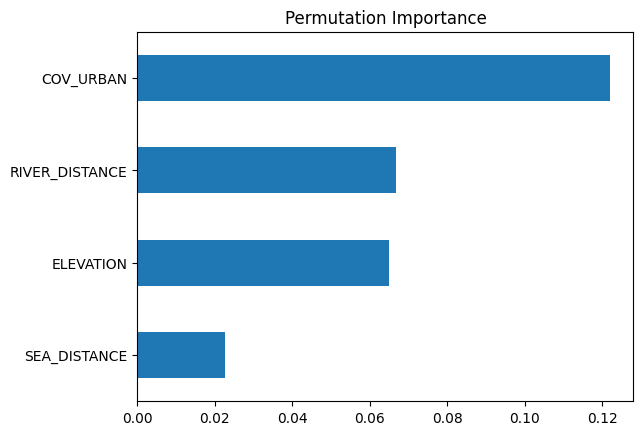

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_test = X_test.to(device)
Y_test = Y_test.to(device)

importances = {}

for f in ["COV_URBAN","ELEVATION","RIVER_DISTANCE","SEA_DISTANCE"]:
    k = X_COLS.index(f)
    importances[f] = permutation_importance(flow, X_test, Y_test, k)

pd.Series(importances).sort_values().plot.barh()
plt.title("Permutation Importance")
plt.show()


#### 8. Calibration / Coverage

In [60]:
def coverage(flow, X, Y, q=90):
    inside = []
    for i in range(200):
        x = X[i:i+1].to(next(flow.parameters()).device)
        s = sample_predictive(flow, x, 2000)
        lo = np.percentile(s, (100-q)/2, axis=0)
        hi = np.percentile(s, 100-(100-q)/2, axis=0)

        y = Y[i].cpu().numpy()
        y = np.expm1(y_scaler.inverse_transform(y.reshape(1,-1)))[0]

        inside.append(np.all((y>=lo)&(y<=hi)))
    return np.mean(inside)


In [61]:
print("90% interval coverage:", coverage(flow, X_test, Y_test))

90% interval coverage: 0.805


### Event simulation

In [62]:
custom_event = {
 'BEGIN_LAT': 35.0,
 'BEGIN_LON': -90.0,
 'DURATION_HOURS': 6,
 'WIND_SPEED': 40,
 'TIME_DAY_SIN': 0.5,
 'TIME_DAY_COS': 0.86,
 'TIME_YEAR_NORM': 0.7,
 'PRECIPITATION': 20,
 'TMIN': 15,
 'TMAX': 28,
 'ELEVATION': 200,
 'SLOPE': 3,
 'COV_BARREN': 0.05,
 'COV_CULTIVATED': 0.40,
 'COV_VEGETATION': 0.30,
 'COV_FOREST': 0.15,
 'COV_WATER': 0.02,
 'COV_SNOW_ICE': 0.00,
 'COV_URBAN': 0.08,
 'RIVER_DISTANCE': 1.5,
 'SEA_DISTANCE': 200
}

In [63]:
x_new = np.array([custom_event[c] for c in X_COLS]).reshape(1,-1)
x_new = x_scaler.transform(x_new)
x_new = torch.tensor(x_new, dtype=torch.float32).to(device)

with torch.no_grad():
    dist = flow(x_new)
    samples = dist.sample((5000,)).squeeze(1)

samples = invert_transform(samples)

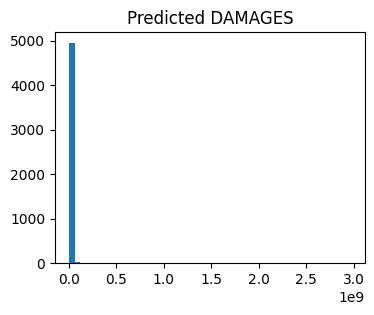

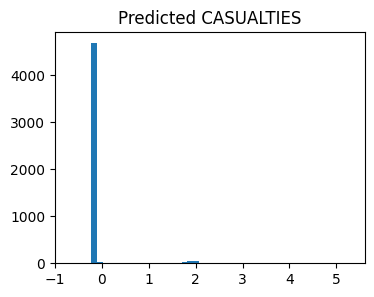

In [64]:
plt.figure(figsize=(4,3))
plt.hist(samples[:,0], bins=50)
plt.title("Predicted DAMAGES")
plt.show()

plt.figure(figsize=(4,3))
plt.hist(samples[:,1], bins=50)
plt.title("Predicted CASUALTIES")
plt.show()


In [65]:
print("Expected damages:", samples[:,0].mean())
print("Median damages:", np.median(samples[:,0]))
print("95% interval:", np.percentile(samples[:,0],[2.5,97.5]))

print("Expected casualties:", samples[:,1].mean())
print("Median casualties:", np.median(samples[:,1]))
print("95% interval:", np.percentile(samples[:,1],[2.5,97.5]))

Expected damages: 6565288.0
Median damages: 1.5668541
95% interval: [1.50379680e+00 2.47036417e+07]
Expected casualties: -0.011989992
Median casualties: -0.12869391
95% interval: [-0.13647343  2.02278847]


#### Counterfactuals

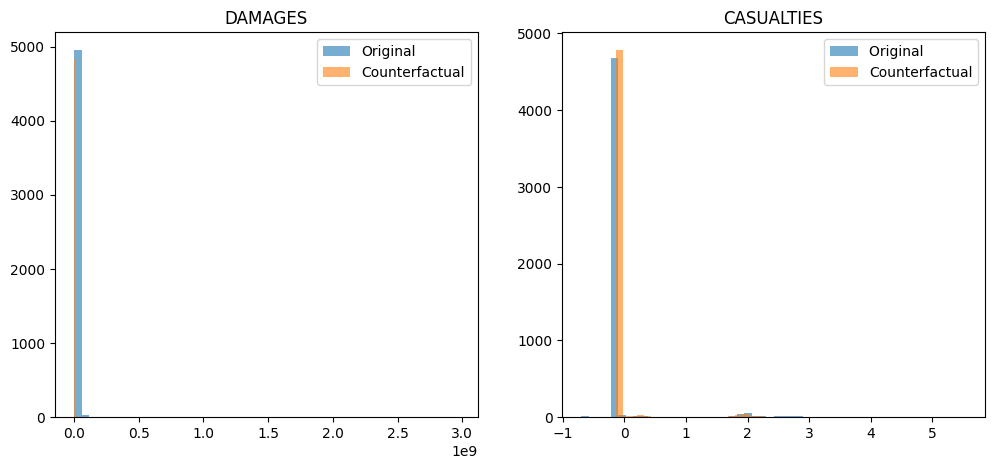

In [66]:
x_cf = x_new.clone()
idx = X_COLS.index("COV_URBAN")
x_cf[0,idx] = (0.5 - x_scaler.mean_[idx]) / x_scaler.scale_[idx]

# Sample again → compare distributions.
with torch.no_grad():
    dist_cf = flow(x_cf)
    samples_cf = dist_cf.sample((5000,)).squeeze(1)

samples_cf = invert_transform(samples_cf)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(samples[:,0], bins=50, alpha=0.6, label="Original")
plt.hist(samples_cf[:,0], bins=50, alpha=0.6, label="Counterfactual")
plt.title("DAMAGES")
plt.legend()
plt.subplot(1,2,2)
plt.hist(samples[:,1], bins=50, alpha=0.6, label="Original ")
plt.hist(samples_cf[:,1], bins=50, alpha=0.6, label="Counterfactual")
plt.title("CASUALTIES")
plt.legend()
plt.show()
